# Isolation Kernels: Dartboard

Do similar executions lead to similar outcomes? We will:

1. **Visualize throws:** show successful, failed, and recovering paths.
2. **Fit isolation regions:** sample centers and examine the effects of psi and partition count.
3. **Embed points:** inspect the sparse features assigned to one observation.
4. **Compare throws:** average point features into a trajectory embedding and compute similarities.
5. **Add direction:** compare a path with its reverse, using states and then transitions.
6. **Compare recent windows:** track similarity to successful training windows before landing.

**Similarity** compares two embeddings. **Familiarity** here is just the average similarity to the nearest nominal windows, not a different kernel or a probability. Below we call it **rolling similarity**.

Use the project's `nb` environment. Run all cells; the Summary figures refresh from the results below.


## Summary


### 1. Visualize throws

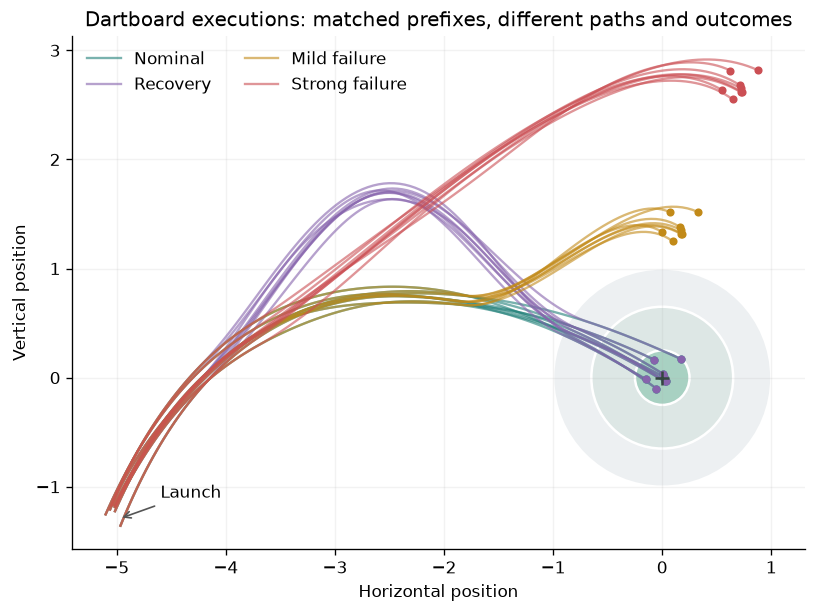

### 2. Fit isolation regions

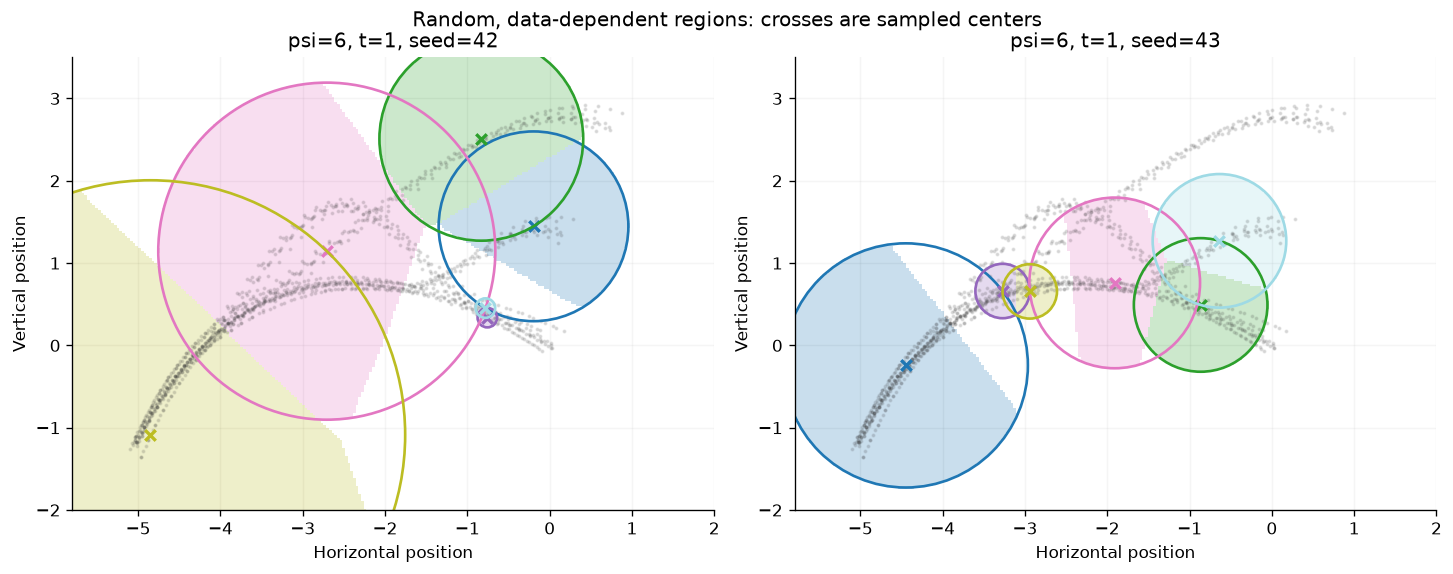

### 3. Embed points

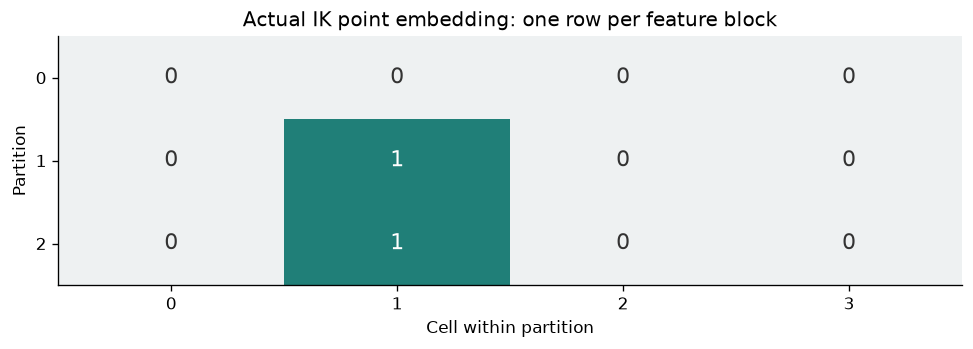

### 4. Compare throws

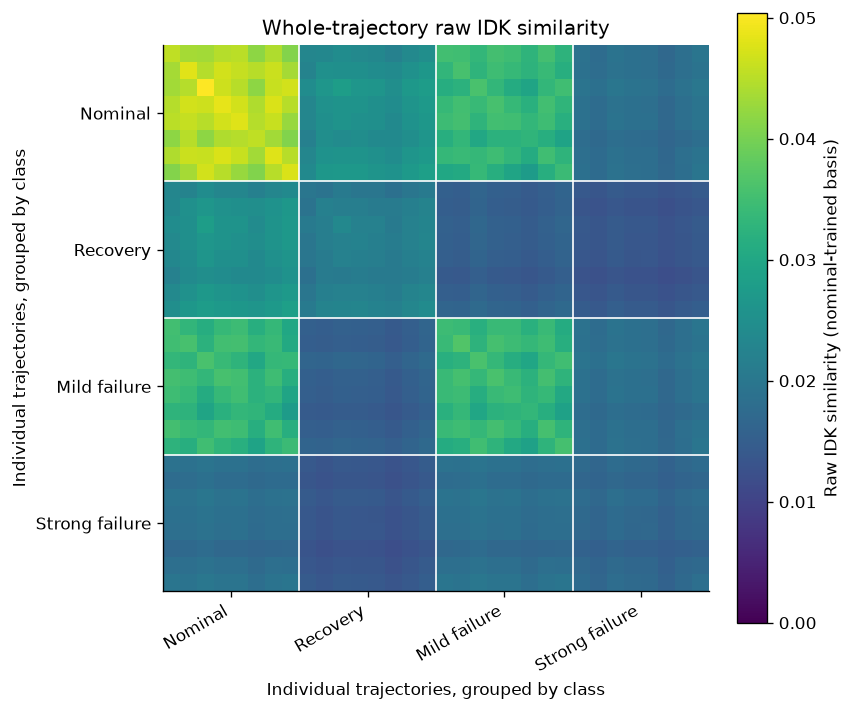

### 5. Add direction

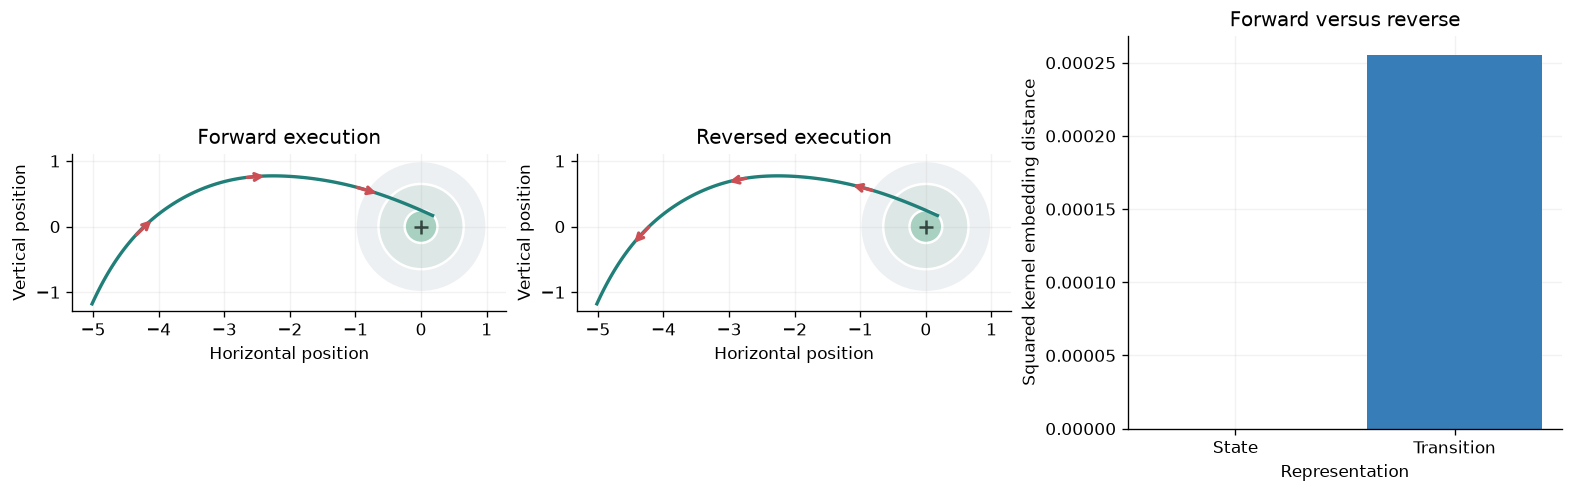

### 6. Compare recent windows

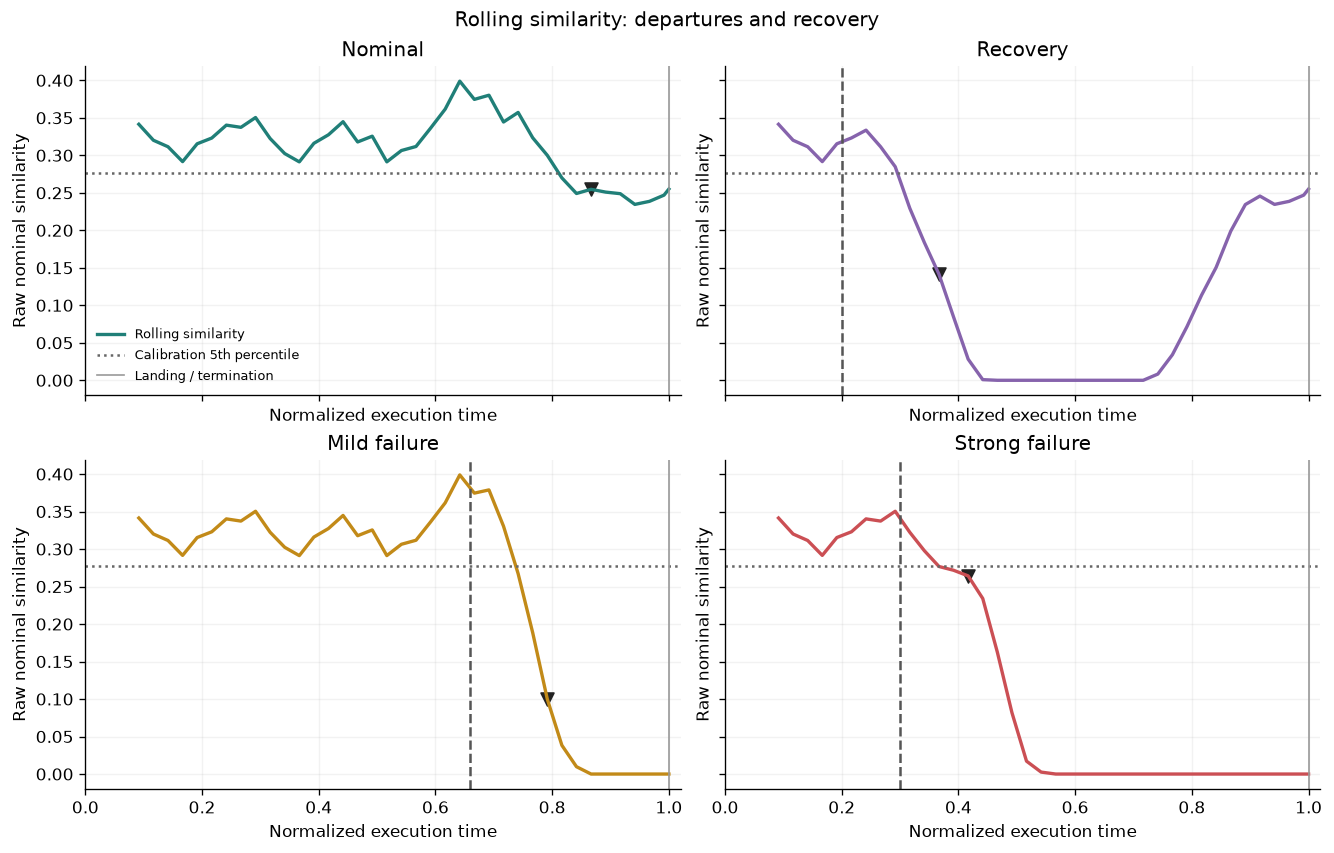

In [1]:
from IPython.display import Markdown, display

SUMMARY = {}
for step in [
    "1. Visualize throws",
    "2. Fit isolation regions",
    "3. Embed points",
    "4. Compare throws",
    "5. Add direction",
    "6. Compare recent windows",
]:
    display(Markdown(f"### {step}"))
    SUMMARY[step] = display(Markdown("Pending run."), display_id=True)

In [2]:
import sys
from collections.abc import Sequence
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.axes import Axes
from matplotlib.colors import ListedColormap
from matplotlib.figure import Figure
from matplotlib.patches import Circle
from numpy.typing import NDArray
from scipy.sparse import csr_matrix

from pyidk import (
    IsolationDistributionalKernel,
    IsolationKernel,
    MinMaxScaler,
    PointRepresentation,
    SequenceBatch,
    Standardizer,
    TransitionRepresentation,
    pairwise_similarity,
)
from pyidk.representation import Representation

# Support execution from either the notebook directory or repository root.
NOTEBOOK_DIR = Path.cwd() if (Path.cwd() / "_synthetic.py").exists() else Path.cwd() / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from _synthetic import dart_throws  # noqa: E402

SEED = 42
COLORS = {
    "Nominal": "#207f78",
    "Recovery": "#8663ac",
    "Mild failure": "#c28a18",
    "Strong failure": "#cb4f54",
    "Frequency": "#377eb8",
    "Amplitude": "#c45b79",
    "Phase": "#8663ac",
    "Local bump": "#be8027",
}
mpl.rcParams.update(
    {
        "figure.figsize": (10, 4.2),
        "figure.dpi": 120,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.16,
        "axes.axisbelow": True,
        "legend.frameon": False,
        "savefig.facecolor": "white",
    }
)
# The fitted representation, feature scaler, and IDK model, in that order.
ExperiencePipeline = tuple[
    Representation, Standardizer | MinMaxScaler, IsolationDistributionalKernel
]

SUMMARY_FIGURES = set()


def show(fig: Figure, key: str | None = None) -> None:
    if key in SUMMARY:
        SUMMARY[key].update(fig)
        SUMMARY_FIGURES.add(key)
    plt.show()
    plt.close(fig)


def batch(sequences: Sequence[NDArray[np.float64]]) -> SequenceBatch:
    return SequenceBatch.from_sequences(sequences)


def fit_experience(
    sequences: Sequence[NDArray[np.float64]],
    representation: Representation,
    *,
    psi: int = 16,
    t: int = 96,
    seed: int = SEED,
    scaler: Standardizer | MinMaxScaler | None = None,
) -> ExperiencePipeline:
    """Fit and return the representation, scaler, and IDK model."""
    represented = representation.transform(batch(sequences))
    scaler = Standardizer() if scaler is None else scaler
    scaler.fit(represented.values)
    scaled = represented.with_values(scaler.transform(represented.values))
    model = IsolationDistributionalKernel(
        IsolationKernel(
            n_partitions=t,
            samples_per_partition=psi,
            random_state=seed,
        )
    ).fit(scaled)
    return representation, scaler, model


def represent(
    pipeline: ExperiencePipeline, sequences: Sequence[NDArray[np.float64]]
) -> SequenceBatch:
    representation, scaler, _ = pipeline
    represented = representation.transform(batch(sequences))
    return represented.with_values(scaler.transform(represented.values))


def embed(pipeline: ExperiencePipeline, sequences: Sequence[NDArray[np.float64]]) -> csr_matrix:
    return pipeline[2].transform(represent(pipeline, sequences))


def squared_distance(
    model: IsolationDistributionalKernel, embeddings: csr_matrix
) -> NDArray[np.float64]:
    similarity = model.similarity(embeddings)
    return np.maximum(
        np.diag(similarity)[:, None] + np.diag(similarity)[None, :] - 2 * similarity, 0
    )

## 1. Visualize throws

Bezier curves share a launch region. Late and early deviations miss the board; recoveries return to a successful endpoint. **Nominal** means an ordinary successful throw without an injected deviation. Separate nominal throws are used for training and calibration.


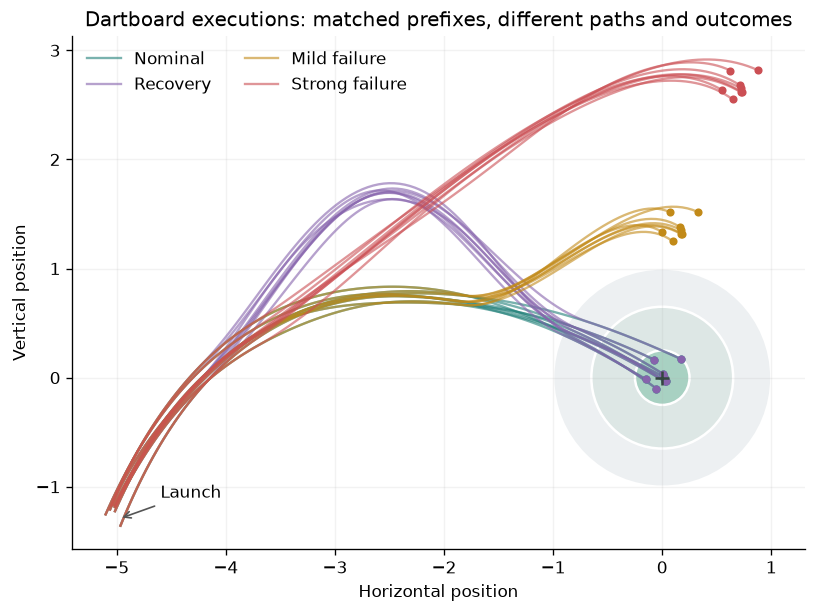

**Generated test set: 32 throws.** Training uses 14 separate nominal throws; calibration uses 8.

| Class | Inner success | Outer / poor | Outside / miss |
|:--|--:|--:|--:|
| Nominal | 8 | 0 | 0 |
| Recovery | 8 | 0 | 0 |
| Mild failure | 0 | 0 | 8 |
| Strong failure | 0 | 0 | 8 |

In [3]:
dart_u, dart_train, dart_cal, dart_groups, dart_onsets = dart_throws(SEED)
dart_names = list(dart_groups)
dart_test = [s for name in dart_names for s in dart_groups[name]]


def board(ax: Axes) -> None:
    for radius, color in [(1.0, "#edf0f2"), (0.65, "#dde7e5"), (0.25, "#a8d1c2")]:
        ax.add_patch(
            Circle((0, 0), radius, facecolor=color, edgecolor="white", linewidth=1.5, zorder=0)
        )
    ax.scatter([0], [0], marker="+", c="#344640", s=65, zorder=4)
    ax.set(xlabel="Horizontal position", ylabel="Vertical position", aspect="equal")


fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
board(ax)
for name, sequences in dart_groups.items():
    for i, sequence in enumerate(sequences):
        ax.plot(*sequence.T, color=COLORS[name], alpha=0.6, lw=1.4, label=name if i == 0 else None)
        ax.scatter(*sequence[-1], s=15, color=COLORS[name], zorder=3)
ax.annotate(
    "Launch",
    xy=dart_train[0][0],
    xytext=(-4.6, -1.1),
    arrowprops={"arrowstyle": "->", "color": "#555555"},
)
ax.set_title("Dartboard executions: matched prefixes, different paths and outcomes")
ax.legend(loc="upper left", ncol=2)
show(fig, "1. Visualize throws")
landing_lines = []
for name, sequences in dart_groups.items():
    radii = np.linalg.norm([s[-1] for s in sequences], axis=1)
    landing_lines.append(
        f"| {name} | {sum(radii <= 0.25)} | "
        f"{sum((radii > 0.25) & (radii <= 1))} | {sum(radii > 1)} |"
    )
display(
    Markdown(
        f"**Generated test set: {len(dart_test)} throws.** Training uses "
        f"{len(dart_train)} separate nominal throws; calibration uses {len(dart_cal)}.\n\n"
        "| Class | Inner success | Outer / poor | Outside / miss |\n"
        "|:--|--:|--:|--:|\n" + "\n".join(landing_lines)
    )
)

## 2. Fit isolation regions

Each sampled center gets a radius equal to its nearest sampled neighbor's distance. A point activates its nearest center only when inside that radius. Circles may overlap, but assignments do not.

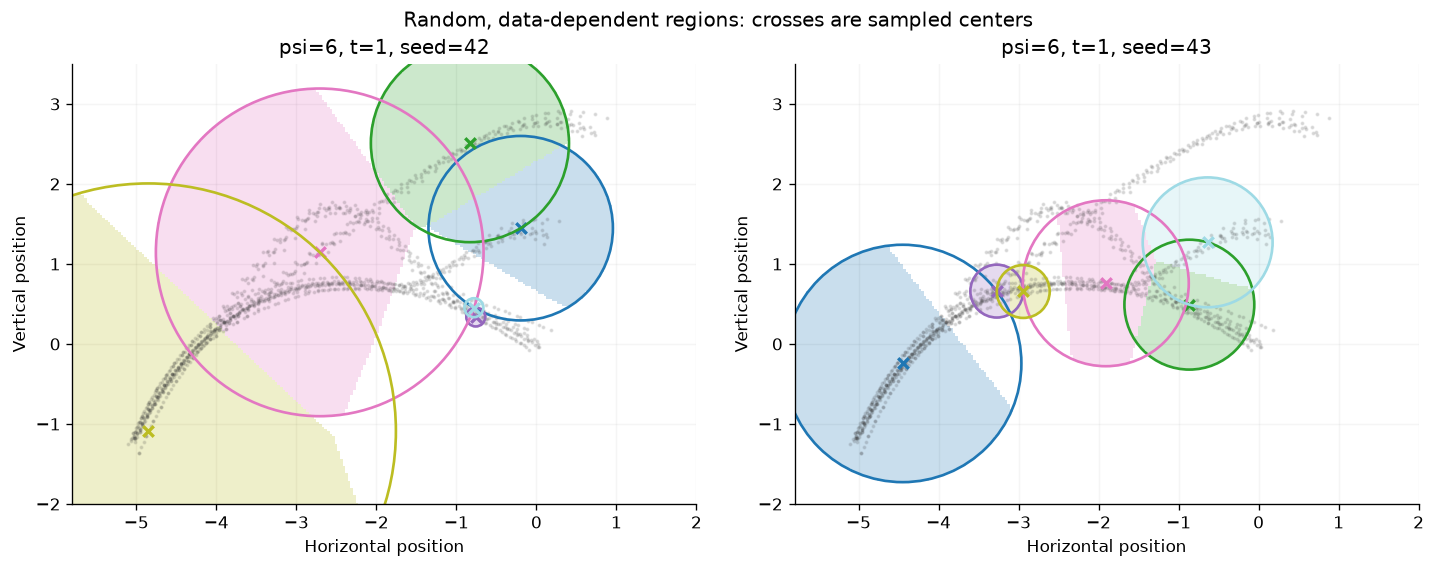

In [4]:
dart_pool = batch(dart_test).values
gx, gy = np.meshgrid(np.linspace(-5.8, 2.0, 240), np.linspace(-2.0, 3.5, 180))
grid = np.column_stack((gx.ravel(), gy.ravel()))


def partition_plot(ax: Axes, psi: int, seed: int) -> IsolationKernel:
    kernel = IsolationKernel(n_partitions=1, samples_per_partition=psi, random_state=seed).fit(
        dart_pool
    )
    basis = kernel.basis_
    assignments = kernel.partitioner.assign(grid, basis)[:, 0].reshape(gx.shape)
    palette = plt.get_cmap("tab20")(np.linspace(0, 1, psi))
    cmap = ListedColormap(np.vstack(([1, 1, 1, 1], palette)))
    ax.pcolormesh(
        gx,
        gy,
        assignments + 1,
        cmap=cmap,
        vmin=-0.5,
        vmax=psi + 0.5,
        alpha=0.24,
        shading="nearest",
        rasterized=True,
    )
    ax.scatter(*dart_pool[::3].T, s=2, color="#333333", alpha=0.12)
    for center, radius, color in zip(basis.centers[0], basis.radii[0], palette, strict=True):
        ax.add_patch(Circle(center, radius, fill=False, edgecolor=color, lw=1.6))
        ax.scatter(*center, c=[color], s=40, marker="x", linewidths=2)
    ax.set(
        xlim=(-5.8, 2),
        ylim=(-2, 3.5),
        aspect="equal",
        xlabel="Horizontal position",
        ylabel="Vertical position",
        title=f"psi={psi}, t=1, seed={seed}",
    )
    return kernel


fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), layout="constrained")
partition_plot(axes[0], 6, SEED)
partition_plot(axes[1], 6, SEED + 1)
fig.suptitle("Random, data-dependent regions: crosses are sampled centers")
show(fig, "2. Fit isolation regions")

### 2.1. Change psi and partition count

Larger psi generally creates finer regions. More partitions average out randomness. The repeated-seed plot holds the compared trajectories fixed; shading shows variation across seeds.


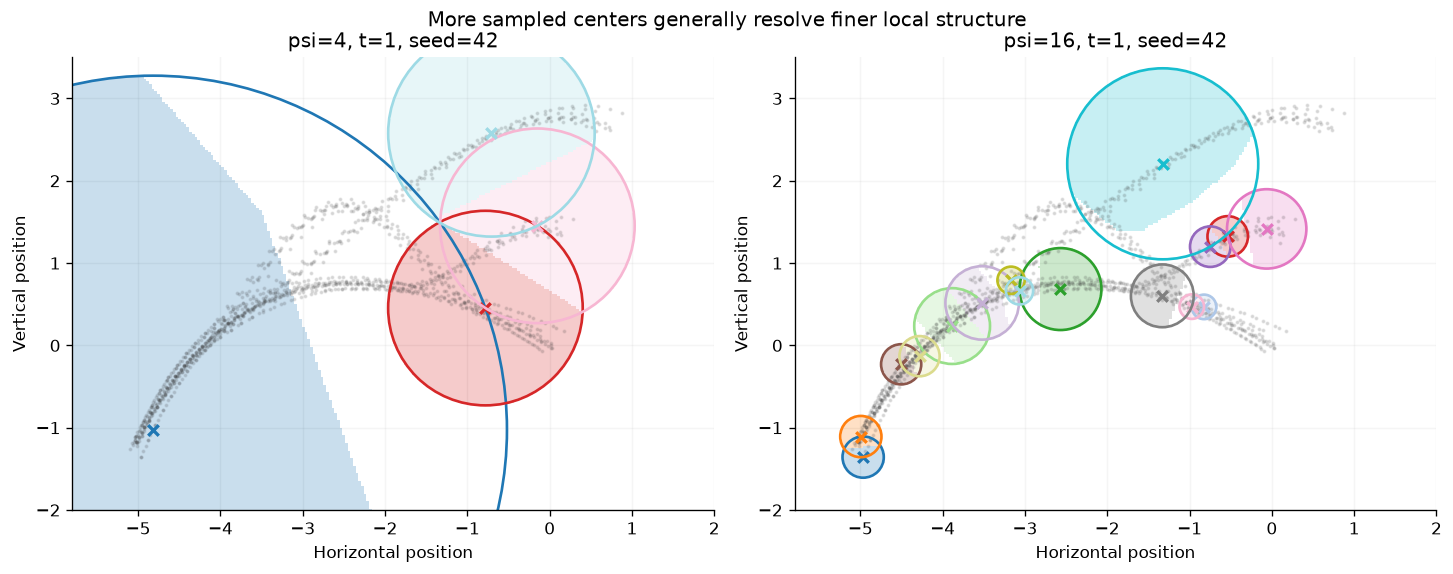

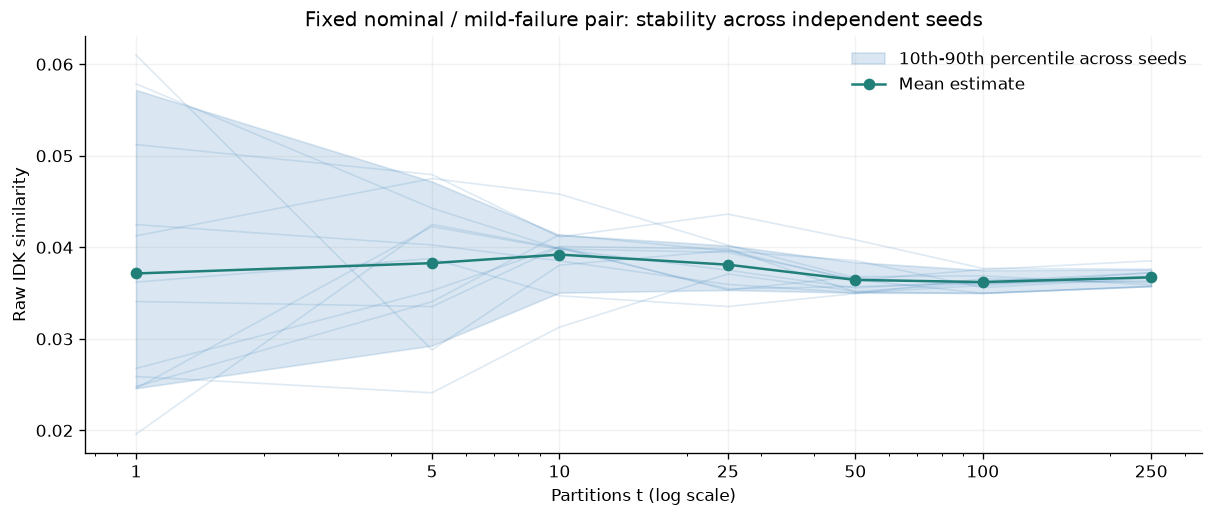

Between-seed standard deviation: **0.0138** at t=1, **0.0008** at t=250. This checks random-basis variability, not generalization across tasks.

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), layout="constrained")
partition_plot(axes[0], 4, SEED)
partition_plot(axes[1], 16, SEED)
fig.suptitle("More sampled centers generally resolve finer local structure")
show(fig)

t_values = np.array([1, 5, 10, 25, 50, 100, 250])
stability = np.empty((12, len(t_values)))
for i in range(len(stability)):
    # Nested prefixes keep the pair and earlier partitions fixed within each seed.
    pipeline = fit_experience(dart_train, PointRepresentation(), t=int(t_values[-1]), seed=1000 + i)
    features = embed(pipeline, [dart_groups["Nominal"][0], dart_groups["Mild failure"][0]])
    for j, t in enumerate(t_values):
        prefix = features[:, : int(t) * 16]
        stability[i, j] = pairwise_similarity(prefix, n_partitions=int(t))[0, 1]
fig, ax = plt.subplots(layout="constrained")
for row in stability:
    ax.plot(t_values, row, color="#377eb8", alpha=0.16, lw=1)
ax.fill_between(
    t_values,
    *np.quantile(stability, [0.1, 0.9], axis=0),
    color="#377eb8",
    alpha=0.18,
    label="10th-90th percentile across seeds",
)
ax.plot(t_values, stability.mean(axis=0), "o-", color="#207f78", label="Mean estimate")
ax.set(
    xscale="log",
    xlabel="Partitions t (log scale)",
    ylabel="Raw IDK similarity",
    title="Fixed nominal / mild-failure pair: stability across independent seeds",
)
ax.set_xticks(t_values, labels=t_values)
ax.legend()
show(fig)
display(
    Markdown(
        f"Between-seed standard deviation: **{stability[:, 0].std(ddof=1):.4f}** "
        f"at t={t_values[0]}, **{stability[:, -1].std(ddof=1):.4f}** at t={t_values[-1]}. "
        "This checks random-basis variability, not generalization across tasks."
    )
)

## 3. Embed points

Each partition contributes at most one active feature. The vector has **t × psi** entries and at most **t** nonzeros. An all-zero block means the point missed its selected sphere.


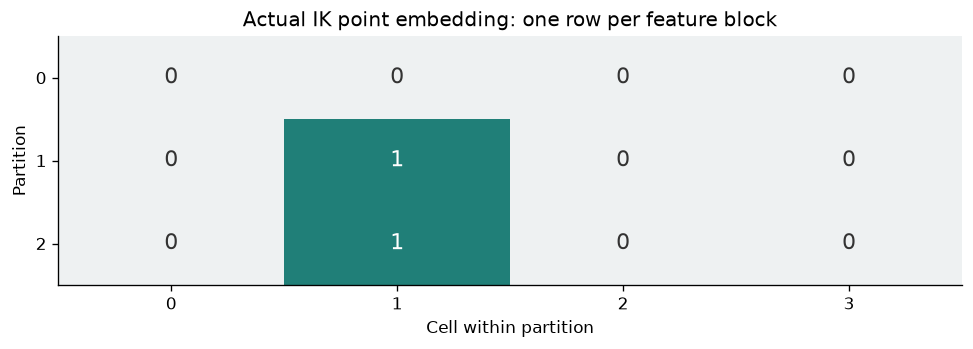

Query = [-2.698, 0.745]; **12 columns**, **2 nonzeros**, stored as **csr_matrix**.

In [6]:
tiny = IsolationKernel(n_partitions=3, samples_per_partition=4, random_state=SEED).fit(dart_pool)
query = dart_groups["Nominal"][0][60:61]
point_feature = tiny.transform(query)
blocks = point_feature.toarray().reshape(3, 4)
fig, ax = plt.subplots(figsize=(8, 2.8), layout="constrained")
ax.imshow(blocks, cmap=ListedColormap(["#eef1f2", "#207f78"]), vmin=0, vmax=1, aspect="auto")
for (i, j), value in np.ndenumerate(blocks):
    ax.text(
        j,
        i,
        str(int(value)),
        ha="center",
        va="center",
        color="white" if value else "#333333",
        fontsize=13,
    )
ax.set(
    xticks=range(4),
    yticks=range(3),
    xlabel="Cell within partition",
    ylabel="Partition",
    title="Actual IK point embedding: one row per feature block",
)
ax.grid(False)
show(fig, "3. Embed points")
display(
    Markdown(
        f"Query = {np.round(query[0], 3).tolist()}; **{point_feature.shape[1]} columns**, "
        f"**{point_feature.nnz} nonzeros**, stored as **{type(point_feature).__name__}**."
    )
)

## 4. Compare throws

Successful training throws define the reference for normal behavior:

1. **Scale coordinates:** subtract the average training x value from every x value, and likewise for y, and divide by its standard deviation to balance x and y in distance calculations.
2. **Build regions:** sample centers from the scaled training points and calculate their isolation radii.
3. **Encode throws:** reuse these scales and regions for every test throw. Each embedding entry is the fraction of its points assigned to one region.

**Raw IDK similarity** is the embeddings' dot product divided by the partition count. It measures shared region membership, not success probability.

Each heatmap cell compares two throws; white lines separate classes.


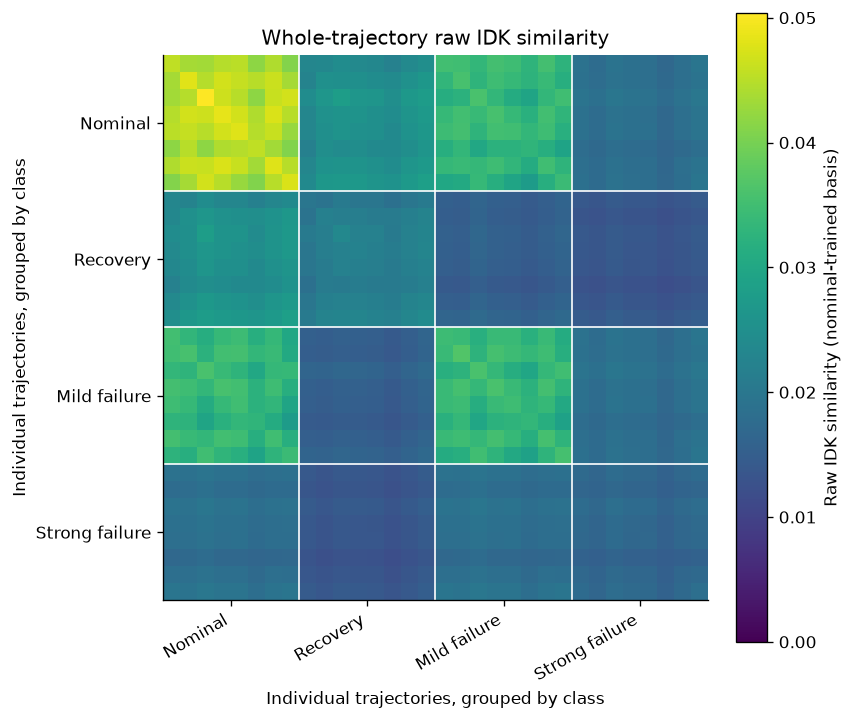

| Test class | Mean raw IDK similarity to nominal training throws |
|:--|--:|
| Nominal | 0.0453 |
| Recovery | 0.0254 |
| Mild failure | 0.0332 |
| Strong failure | 0.0185 |

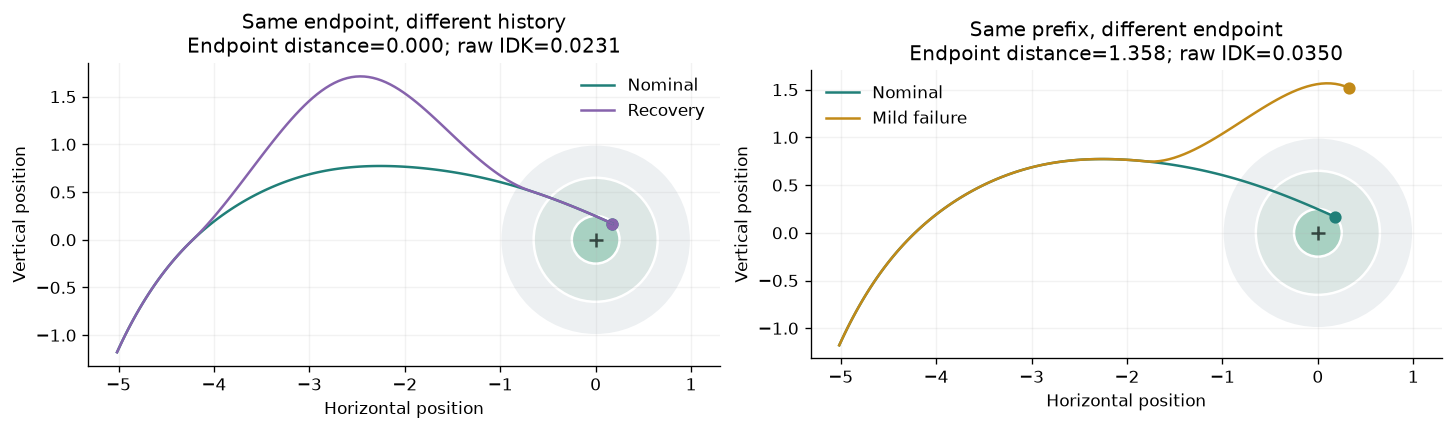

In [7]:
dart_pipeline = fit_experience(dart_train, PointRepresentation())
dart_model = dart_pipeline[2]
dart_embeddings = embed(dart_pipeline, dart_test)
dart_similarity = dart_model.similarity(dart_embeddings)
assert np.allclose(dart_similarity, dart_similarity.T)
fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
im = ax.imshow(dart_similarity, cmap="viridis", vmin=0)
bounds = np.cumsum([len(dart_groups[name]) for name in dart_names])
starts = np.r_[0, bounds[:-1]]
centers = (starts + bounds - 1) / 2
ax.set(
    xticks=centers,
    yticks=centers,
    xticklabels=dart_names,
    yticklabels=dart_names,
    xlabel="Individual trajectories, grouped by class",
    ylabel="Individual trajectories, grouped by class",
    title="Whole-trajectory raw IDK similarity",
)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
for boundary in bounds[:-1] - 0.5:
    ax.axhline(boundary, color="white", lw=1)
    ax.axvline(boundary, color="white", lw=1)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Raw IDK similarity (nominal-trained basis)")
show(fig, "4. Compare throws")
reference_embedding = embed(dart_pipeline, dart_train)
class_means = dart_model.similarity(dart_embeddings, reference_embedding).mean(axis=1)
display(
    Markdown(
        "| Test class | Mean raw IDK similarity to nominal training throws |\n|:--|--:|\n"
        + "\n".join(
            f"| {name} | {class_means[start:end].mean():.4f} |"
            for name, start, end in zip(dart_names, starts, bounds, strict=True)
        )
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
for ax, other, title in zip(
    axes,
    ["Recovery", "Mild failure"],
    ["Same endpoint, different history", "Same prefix, different endpoint"],
    strict=True,
):
    board(ax)
    nominal, changed = dart_groups["Nominal"][0], dart_groups[other][0]
    for name, sequence in [("Nominal", nominal), (other, changed)]:
        ax.plot(*sequence.T, color=COLORS[name], label=name)
        ax.scatter(*sequence[-1], c=COLORS[name], s=40)
    distance = np.linalg.norm(nominal[-1] - changed[-1])
    similarity = dart_model.similarity(embed(dart_pipeline, [nominal, changed]))[0, 1]
    ax.set_title(f"{title}\nEndpoint distance={distance:.3f}; raw IDK={similarity:.4f}")
    ax.legend()
show(fig)

## 5. Add direction

Reversing a path leaves its state distribution unchanged. Ordered pairs **[current state, next state]** preserve local direction, so their embeddings can differ. Averaging transitions still loses their global order.


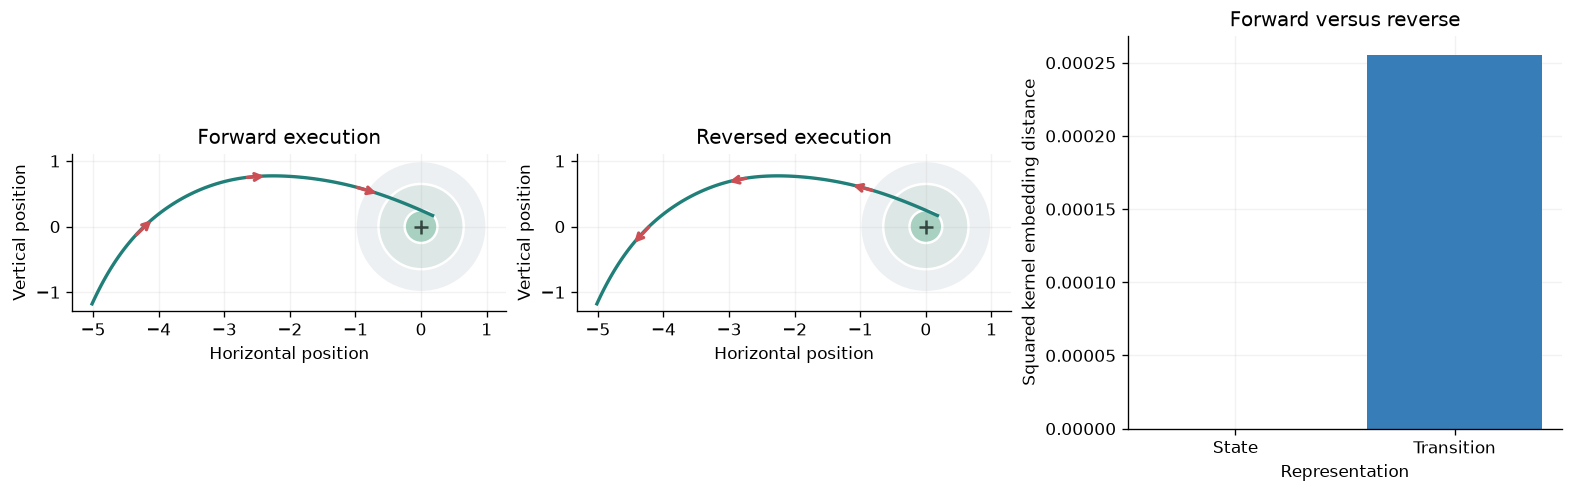

Maximum state-feature difference: **0.00e+00**. Transition squared distance: **0.00026**. This example distinguishes direction; averaging transitions still discards their global order and does not uniquely encode every sequence.

In [8]:
forward = dart_groups["Nominal"][0]
reverse = forward[::-1].copy()
state_pair = embed(dart_pipeline, [forward, reverse])
state_error = np.max(np.abs((state_pair[0] - state_pair[1]).toarray()))
assert state_error < 1e-12

transition_pipeline = fit_experience(dart_train, TransitionRepresentation())
transition_pair = embed(transition_pipeline, [forward, reverse])
transition_distance = squared_distance(transition_pipeline[2], transition_pair)[0, 1]
assert transition_distance > 1e-8
fig, axes = plt.subplots(1, 3, figsize=(13, 4), layout="constrained")
for ax, sequence, title in zip(
    axes[:2], [forward, reverse], ["Forward execution", "Reversed execution"], strict=True
):
    board(ax)
    ax.plot(*sequence.T, color="#207f78", lw=2)
    for i in [20, 60, 95]:
        ax.annotate(
            "",
            xy=sequence[i + 8],
            xytext=sequence[i],
            arrowprops={"arrowstyle": "->", "color": "#cb4f54", "lw": 2},
        )
    ax.set_title(title)
distances = [squared_distance(dart_model, state_pair)[0, 1], transition_distance]
axes[2].bar(["State", "Transition"], distances, color=["#207f78", "#377eb8"])
axes[2].set(
    ylabel="Squared kernel embedding distance",
    xlabel="Representation",
    title="Forward versus reverse",
)
show(fig, "5. Add direction")
display(
    Markdown(
        f"Maximum state-feature difference: **{state_error:.2e}**. "
        f"Transition squared distance: **{transition_distance:.5f}**. "
        "This example distinguishes direction; averaging transitions still discards their "
        "global order and does not uniquely encode every sequence."
    )
)

## 6. Compare recent windows

Average each recent window's similarities to its nearest nominal training windows. Timestamp the score at the last observation consumed.

A calibration threshold and consecutive low scores define an illustrative alarm. Dashed lines mark injected deviations. Recovery and nominal false alarms show why low similarity does not prove failure.


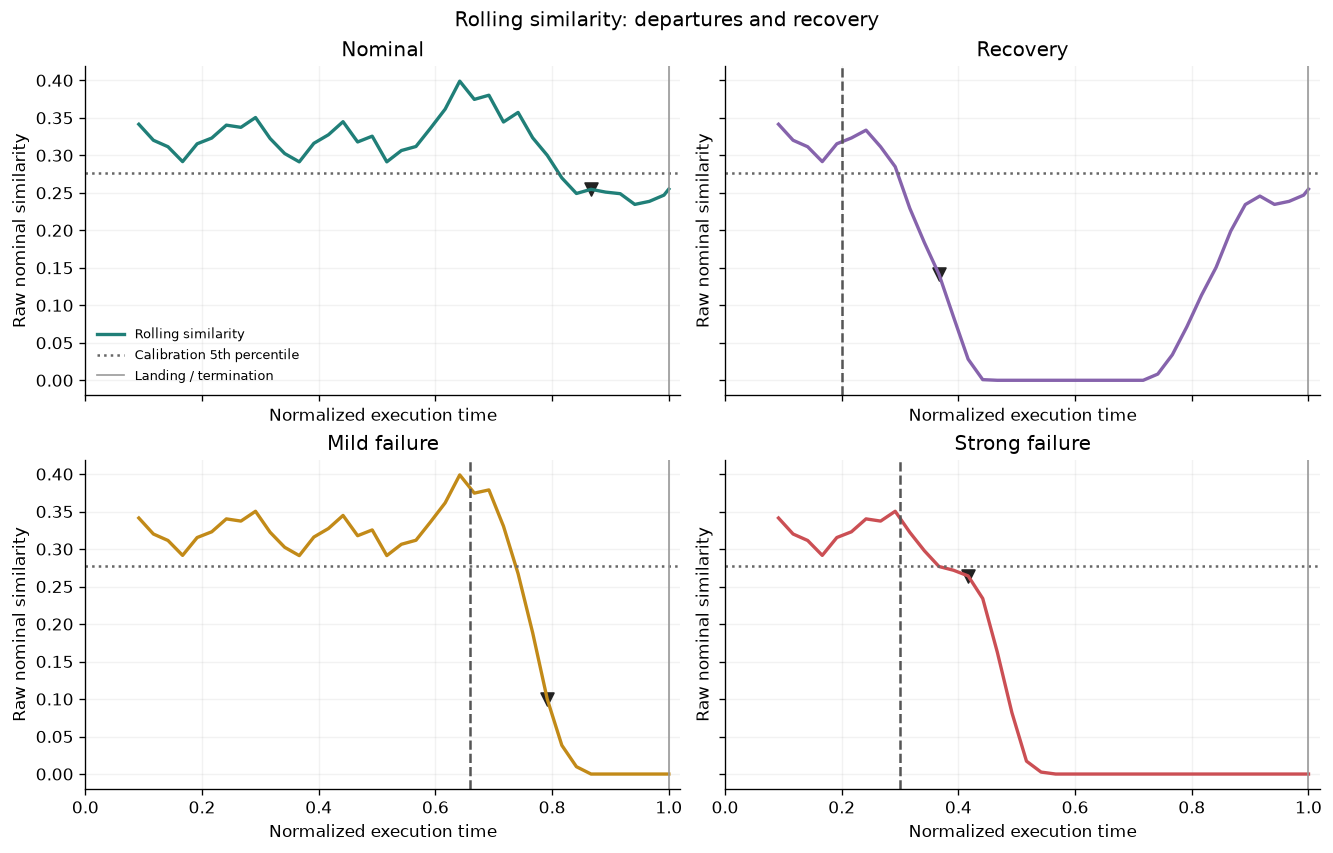

| Execution | Injected onset | First sustained alarm after onset | Time before landing |
|:--|--:|--:|--:|
| Nominal | none | 0.867 | 0.133 |
| Recovery | 0.20 | 0.367 | 0.633 |
| Mild failure | 0.66 | 0.792 | 0.208 |
| Strong failure | 0.30 | 0.417 | 0.583 |

In [9]:
def rolling_embeddings(
    pipeline: ExperiencePipeline,
    sequences: Sequence[NDArray[np.float64]],
    *,
    width: int = 12,
    stride: int = 3,
) -> tuple[csr_matrix, list[NDArray[np.float64]], NDArray[np.int64]]:
    """Return window embeddings, per-sequence end times, and embedding row offsets."""
    represented = represent(pipeline, sequences)
    windows, endpoints = [], []
    for i, sequence in enumerate(sequences):
        rows = represented.sequence(i)
        offset = len(sequence) - len(rows)  # All representations here have stride 1.
        ends = np.arange(width - 1, len(rows), stride)
        if ends[-1] != len(rows) - 1:
            ends = np.r_[ends, len(rows) - 1]
        windows.extend(rows[end - width + 1 : end + 1] for end in ends)
        endpoints.append((ends + offset) / (len(sequence) - 1))
    embeddings = pipeline[2].transform(batch(windows))
    counts = [len(end) for end in endpoints]
    return embeddings, endpoints, np.r_[0, np.cumsum(counts)]


def rolling_scores(
    pipeline: ExperiencePipeline,
    sequences: Sequence[NDArray[np.float64]],
    reference: csr_matrix,
    *,
    width: int = 12,
    stride: int = 3,
    k: int = 5,
) -> tuple[list[NDArray[np.float64]], list[NDArray[np.float64]]]:
    """Return per-sequence window end times and matching similarity scores."""
    embeddings, endpoints, offsets = rolling_embeddings(
        pipeline,
        sequences,
        width=width,
        stride=stride,
    )
    similarity = pipeline[2].similarity(embeddings, reference)
    k = min(k, similarity.shape[1])
    scores = np.partition(similarity, -k, axis=1)[:, -k:].mean(axis=1)
    return endpoints, [scores[a:b] for a, b in zip(offsets[:-1], offsets[1:], strict=True)]


def first_alarm(
    times: NDArray[np.float64],
    scores: NDArray[np.float64],
    threshold: float,
    onset: float = 0.0,
    persistence: int = 3,
) -> float:
    low = scores < threshold
    for end in range(persistence - 1, len(low)):
        start = end - persistence + 1
        if times[start] >= onset and low[start : end + 1].all():
            return float(times[end])  # Alarm time is when persistence is confirmed.
    return np.nan


dart_reference, _, _ = rolling_embeddings(dart_pipeline, dart_train, stride=6)
cal_times, cal_scores = rolling_scores(dart_pipeline, dart_cal, dart_reference)
dart_threshold = np.quantile(np.concatenate(cal_scores), 0.05)
chosen = [dart_groups[name][0] for name in dart_names]
dart_times, dart_scores = rolling_scores(dart_pipeline, chosen, dart_reference)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True, layout="constrained")
dart_alarm_rows = []
for ax, name, times, scores in zip(axes.flat, dart_names, dart_times, dart_scores, strict=True):
    ax.plot(times, scores, color=COLORS[name], lw=2, label="Rolling similarity")
    ax.axhline(dart_threshold, color="#666666", ls=":", label="Calibration 5th percentile")
    onset = dart_onsets[name]
    if onset is not None:
        ax.axvline(onset, color="#555555", ls="--", label="Deviation onset")
    ax.axvline(1, color="#999999", lw=1, label="Landing / termination")
    alarm = first_alarm(times, scores, dart_threshold, onset or 0)
    if np.isfinite(alarm):
        ax.scatter(alarm, np.interp(alarm, times, scores), marker="v", s=60, c="#222222")
    ax.set(
        title=name,
        xlabel="Normalized execution time",
        ylabel="Raw nominal similarity",
        xlim=(0, 1.02),
    )
    dart_alarm_rows.append(
        f"| {name} | {'none' if onset is None else f'{onset:.2f}'} | "
        f"{'not detected' if np.isnan(alarm) else f'{alarm:.3f}'} | "
        f"{'n/a' if np.isnan(alarm) else f'{1 - alarm:.3f}'} |"
    )
axes[0, 0].legend(fontsize=8)
fig.suptitle("Rolling similarity: departures and recovery")
show(fig, "6. Compare recent windows")
display(
    Markdown(
        "| Execution | Injected onset | First sustained alarm after onset | Time before landing |\n"
        "|:--|--:|--:|--:|\n" + "\n".join(dart_alarm_rows)
    )
)

assert point_feature.nnz <= tiny.n_partitions
assert state_error < 1e-12 and transition_distance > 0
assert len(SUMMARY_FIGURES) == len(SUMMARY)
for name in ["Mild failure", "Strong failure", "Recovery"]:
    before = dart_u <= dart_onsets[name]
    assert np.allclose(dart_groups[name][0][before], dart_groups["Nominal"][0][before])